#**Detecting Fake Reviews with Attention**





#*An Attention Layer from Scratch*

Let's try another approach to deciding which words are more or less important in a sequence, depending on the context of all words seen. We are going to implement a hard-coded attention mechanism here, from scratch.

Let's reimport and process our dataset as before.

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from google.colab import files
import pandas as pd
import io
import numpy as np

from google.colab import drive

drive.mount('/content/drive')
reviews = pd.read_csv("/content/drive/MyDrive/Teaching/Courses/NYU - Modern AI/2026/Lecture Materials/3 - RNNs and Transformers/dataset/fake reviews dataset.csv")

label = np.where(reviews['label']=='CG',1,0)
reviews = np.array(reviews['text_'])

print(reviews[2])

Mounted at /content/drive
This pillow saved my back. I love the look and feel of this pillow.


Let's make a TextVectorization() layer to preprocess our text.

In [ ]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=20000,
    output_mode="multi_hot", # This is requesting multihot encodings (which means we'll have a fixed vector of 1's and 0's per review)
)

text_vectorization.adapt(reviews)

We are going to start off with one-hot encodings again, just to make sure we understand the shapes of all the tensors and things as we go along, so we understand what the network is doing!

In [ ]:
processed_text = text_vectorization(reviews)

# We have 40,432 reviews, with 20000 binary word dummy indicators for our vocab.
print(processed_text.shape)

(40432, 20000)


In [ ]:
processed_text[0]

<tf.Tensor: shape=(20000,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 0])>

Now we can make our network... notice that we have extremely few trainable weights in here... only the final dense layer has any weights!

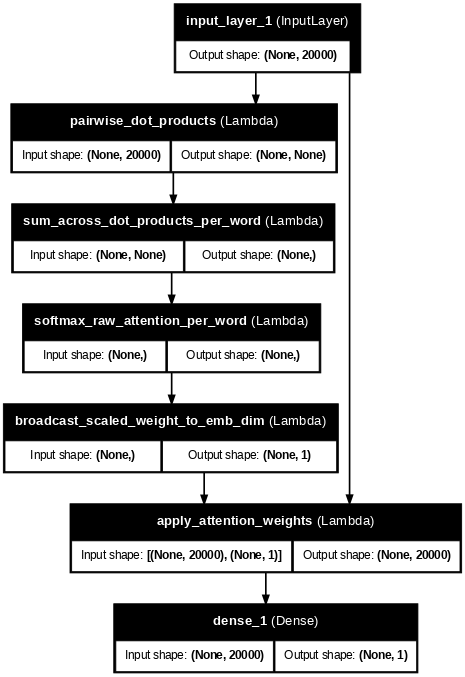

In [ ]:
from keras.layers import Flatten, Activation, RepeatVector, Permute, Multiply, Lambda, Dense


# Now, let's start specifying our model...
inputs = keras.layers.Input(shape=[20000,]) # We take the sequence of 1-hot encodings as input.

# 1. Calculate dot products between all pairs of word embeddings
dot_products = Lambda(lambda x: tf.matmul(x, x, transpose_b=True),name="pairwise_dot_products")(inputs)  # (batch_size, seq_len, seq_len)

# 2. Sum dot products for each word to get attention scores
attention_scores = Lambda(lambda x: tf.reduce_sum(x, axis=-1),name="sum_across_dot_products_per_word")(dot_products)  # (batch_size, seq_len)

# 3. Apply softmax to normalize attention scores
attention_weights = Lambda(lambda x: tf.nn.softmax(x, axis=-1),name="softmax_raw_attention_per_word")(attention_scores)  # (batch_size, seq_len)

# 4. Reshape attention weights for broadcasting
attention_weights = Lambda(lambda x: tf.expand_dims(x, axis=-1),name="broadcast_scaled_weight_to_emb_dim")(attention_weights)  # (batch_size, seq_len, 1)

# 5. Per focal word (embedding), multiply each embedding in the sequence by its attention weight, then sum all the weighted embeddings together to get the adjusted embedding for the focal word.
# We do this in parallel for each word in the sequence, shifting / adjusting the embedding vector 'toward' the most relevant *other* words in the seqeunce.
attention_output = Lambda(lambda x: x[0] * x[1],name="apply_attention_weights")([inputs, attention_weights])  # (batch_size, seq_len, embedding_dim)

outputs = keras.layers.Dense(1, activation="sigmoid")(attention_output)

model = keras.Model(inputs,outputs)
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=['accuracy'])

keras.utils.plot_model(model,show_shapes=True,dpi=60,show_layer_names=True)

How many trainable parameters are in this NN? Just 20,000! Anyd they are all in the final dense layer.

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pairwise_dot_produ… │ (None, None)      │          0 │ input_layer_1[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_across_dot_pro… │ (None)            │          0 │ pairwise_dot_pro… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_raw_attent… │ (None)            │          0 │ sum_across_dot_p… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ broadcast_scaled_w… │ (None, 1)         │          0 │ softmax_raw_atte… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_attention_we… │ (None, 20000)     │          0 │ input_layer_1[0]… │
│ (Lambda)            │                   │            │ broadcast_scaled… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │     20,001 │ apply_attention_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,004 (156.27 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,003 (78.14 KB)

And, let's try fitting this model... our hard-coded attention mechanism does quite well!

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/Teaching/Courses/NYU - Modern AI/2026/Lecture Materials/3 - RNNs and Transformers/attention_from_scratch.keras",
                                    save_best_only=True)
]

history = model.fit(processed_text, label,
                        validation_split=0.2,
                        epochs=20, batch_size=28,callbacks=callbacks)

Epoch 1/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step - accuracy: 0.8258 - loss: 0.4035 - val_accuracy: 0.8352 - val_loss: 0.3707
Epoch 2/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 0.8752 - loss: 0.2920 - val_accuracy: 0.8407 - val_loss: 0.3863
Epoch 3/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 0.8843 - loss: 0.2900 - val_accuracy: 0.8410 - val_loss: 0.4056
Epoch 4/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - accuracy: 0.8873 - loss: 0.2939 - val_accuracy: 0.8406 - val_loss: 0.4345
Epoch 5/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - accuracy: 0.8913 - loss: 0.2970 - val_accuracy: 0.8444 - val_loss: 0.4362
Epoch 6/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 0.8938 - loss: 0.2992 - val_accuracy: 0.8431 - val_loss: 0.4611
Epoch 7/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 0.8964 - loss: 0.3064 - val_accuracy: 0.8447 - val_loss: 0.4783
Epoch 8/20
32345/32345 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 

And, plotting model performance, as well as evaluating against the test set, what do we get... our best model yields about 80% accuracy in the test data.

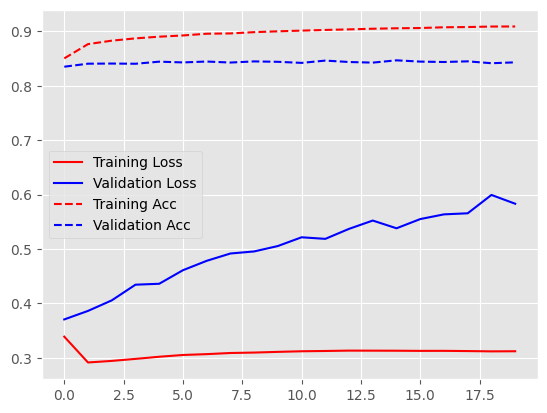

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'],c="b")
plt.plot(history.history['accuracy'],c="r",linestyle="--")
plt.plot(history.history['val_accuracy'],c="b",linestyle="--")
plt.legend(['Training Loss','Validation Loss','Training Acc','Validation Acc'])
plt.show()

#*QKV Framework Attention Layer*

In [6]:
text_vectorization = keras.layers.TextVectorization(
    output_mode="int", # This is requesting integer indices (a unique integer represents a certain word)
)

text_vectorization.adapt(reviews)

processed_text = text_vectorization(reviews)

# We have 40,000+ reviews, with up to 373 tokens in each sequence (including padding)
print(processed_text.shape)

print(processed_text[0])

print(reviews[0])

(40432, 373)
tf.Tensor(
[  33    9   37   99  208    5   18  124    4   33 1453  156    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0   

We can leverage the code from the book for a Transformer of course.

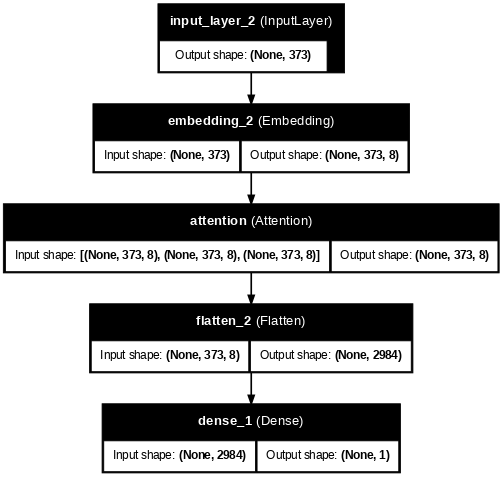

In [8]:
from keras.layers import Flatten, Dense

# Now, let's start specifying our model...
inputs = keras.layers.Input(shape=(373,)) # We take the sequence of integer encodings as input.

# Map 20,000 integer indices to 8-dimensional embedding space
embedding_layer = layers.Embedding(20_000,8)
embeddings = embedding_layer(inputs)

# We implement self-attention here; the input serves as the query, the key (comparison), and is also the value against which attention scores are applied.
attention_weighted_embeddings = keras.layers.Attention()([embeddings,embeddings,embeddings])

flatten = layers.Flatten()(attention_weighted_embeddings)

outputs = keras.layers.Dense(1, activation="sigmoid")(flatten)

model = keras.Model(inputs,outputs)
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=['accuracy'])

keras.utils.plot_model(model,show_shapes=True,dpi=60,show_layer_names=True)

Now how many parameters does our model have? 160,000+ weights.

In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 373)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 373, 8)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2984)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,985 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,985 (636.66 KB)

 Trainable params: 162,985 (636.66 KB)

 Non-trainable params: 0 (0.00 B)

Now we fit our model. The model starts off worse, but it quickly surpasses accuracy obtained using the hard-coded attention rule we implemented above. The key innovation here is that we first multiply the input vector for a review by three weight matrices, the Query, Key, and Value weight matrices. This yields three new 'versions' of each token input, which are then used to implement the same attention rule we hard coded earlier on the raw inputs.

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/Teaching/Courses/NYU - Modern AI/2026/Lecture Materials/3 - RNNs and Transformers/keras_model.keras",
                                    save_best_only=True)
]

history = model.fit(processed_text, label,
                        validation_split=0.2,
                        epochs=20, batch_size=32,callbacks=callbacks)

Epoch 1/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.7556 - loss: 0.5201 - val_accuracy: 0.8720 - val_loss: 0.2961
Epoch 2/20
 337/1011 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9340 - loss: 0.1866

KeyboardInterrupt: 

And plotting loss over training, we end up close to 90% accuracy on the validation sample.

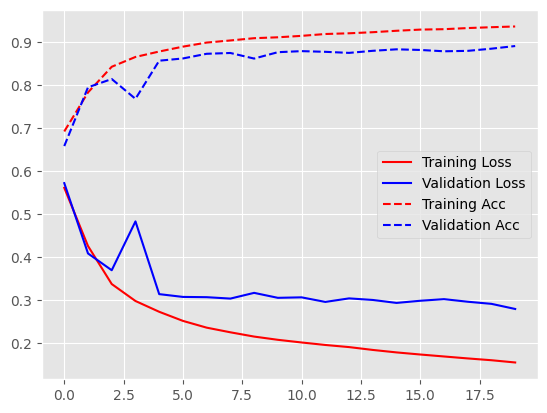

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'],c="b")
plt.plot(history.history['accuracy'],c="r",linestyle="--")
plt.plot(history.history['val_accuracy'],c="b",linestyle="--")
plt.legend(['Training Loss','Validation Loss','Training Acc','Validation Acc'])
plt.show()